# Benchmark 3 — fRG physics sanity checks

This notebook is a **physics benchmark notebook** for your existing kagome fRG pipeline.

It does **not** redesign the code.  
It uses your current modules to test whether the implementation behaves like the one-loop temperature-flow equation should.

The relevant flow equation is the one-loop level-2 truncation in Metzner *et al.*, where the vertex flow is the sum of **pp**, **direct ph**, and **crossed ph** contributions, each bilinear in the two-particle vertex and one loop bubble. In particular, if the vertex is zero, the right-hand side must also vanish. fileciteturn0file0L794-L814

---

## What this notebook checks

1. **Zero-interaction test**  
2. **Weak-coupling scaling**  
3. **SU(2) spin symmetry**  
4. **Channel competition**  
5. **Momentum-structure sanity**  
6. **Short flow stability**  
7. **Order-diagnosis consistency**

---

## General interpretation rule

For all symmetry / zero tests, use a relative error of roughly

\[
10^{-10}\text{ to }10^{-8}
\]

as “excellent”, depending on patch matching and floating-point accumulation.

For flow / scaling tests, the question is **trend correctness**, not machine precision.


## Cell 1 — Imports

Use your current pipeline only.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from noninteracting import KagomeKaneMeleSOC, KagomeStaggerFlux, KagomeNagaosa
from patching import FSPatcher
from interaction import BareExtendedHubbard
from channels import ChannelDecomposer
from frg_kernel import (
    FlowConfig,
    compute_pp_kernel,
    compute_ph_kernel,
    compute_phc_kernel,
)
from kagome_order_diagnosis import KagomeOrderDiagnoser

# Optional: only if your current Module 4 solver exists and works
try:
    from frg_flow import FRGFlowSolver, BareVertexFromInteraction
    HAS_FLOW_SOLVER = True
except Exception:
    HAS_FLOW_SOLVER = False
    print("frg_flow.py not available or not importable; flow tests will be notebook-design only.")


## Cell 2 — Common helpers

These helpers keep the benchmark cells short and make the tests comparable.


In [3]:
def build_spin_patchsets(model, mu, band_index=1, Npatch=12, grid_size=220):
    patch_up = FSPatcher(
        model,
        band_index=band_index,
        mu=mu,
        Npatch=Npatch,
        grid_size=grid_size,
        orbital_slice=slice(0, 3),
        gauge_fix="parallel_transport",
    ).build()

    patch_dn = FSPatcher(
        model,
        band_index=band_index,
        mu=mu,
        Npatch=Npatch,
        grid_size=grid_size,
        orbital_slice=slice(3, 6),
        gauge_fix="parallel_transport",
    ).build()

    return {"up": patch_up, "dn": patch_dn}


def build_reference_model_and_patchsets(
    *,
    model_name="kane_mele",
    parameters=None,
    filling=0.50,
    Npatch=12,
    grid_size=220,
    band_index=1,
):
    if model_name == "kane_mele":
        if parameters is None:
            parameters = {"t": 1.0, "l1": 0.0, "l2": 0.0}
        model = KagomeKaneMeleSOC(parameters=parameters, spin=True, B=0.0)
    elif model_name == "stagger_flux":
        if parameters is None:
            parameters = {"t": 1.0, "phi": 0.0}
        model = KagomeStaggerFlux(parameters=parameters, spin=True, B=0.0)
    elif model_name == "nagaosa":
        if parameters is None:
            parameters = {"t": 1.0, "phi": 0.0}
        model = KagomeNagaosa(parameters=parameters, spin=True, B=0.0)
    else:
        raise ValueError("Unknown model_name")

    mu = model.EF_from_filling(filling)
    patchsets = build_spin_patchsets(model, mu, band_index=band_index, Npatch=Npatch, grid_size=grid_size)
    return model, mu, patchsets


def make_interaction(model, U, V):
    return BareExtendedHubbard.from_kagome_model(model, U=U, V=V)


def block_tensor_norm(T):
    arr = np.asarray(T)
    return float(np.max(np.abs(arr)))


def kernel_norm(kernel):
    return float(np.max(np.abs(kernel.matrix)))


def relative_diff(a, b, floor=1e-14):
    a = np.asarray(a)
    b = np.asarray(b)
    denom = max(float(np.max(np.abs(a))), float(np.max(np.abs(b))), floor)
    return float(np.max(np.abs(a - b)) / denom)


def build_gamma_tensors(interaction, patchsets):
    spin_blocks = [
        ("up", "up", "up", "up"),
        ("dn", "dn", "dn", "dn"),
        ("up", "dn", "up", "dn"),
        ("up", "dn", "dn", "up"),
        ("dn", "up", "up", "dn"),
        ("dn", "up", "dn", "up"),
    ]
    out = {}
    for key in spin_blocks:
        s1, s2, s3, s4 = key
        out[key] = interaction.patch_tensor(
            patchsets, s1, s2, s3, s4,
            antisym=True,
            enforce_momentum=False,
        )
    return out


def pick_test_Qs(patchsets, n_pick=6):
    patch_up = patchsets["up"]
    ks = patch_up.patch_k
    idx = np.linspace(0, len(ks)-1, num=min(n_pick, len(ks)), dtype=int)
    return [ks[i] for i in idx]


def compute_basic_channel_set(gamma, patchsets, Q, T=0.20, nfreq=64):
    cfg = FlowConfig(temperature=T, nfreq=nfreq, include_explicit_T_prefactor=True)

    out = {}
    try:
        out["pp_ud_ud"] = compute_pp_kernel(
            gamma, patchsets, Q,
            incoming_spins=("up", "dn"),
            outgoing_spins=("up", "dn"),
            config=cfg,
        )
    except Exception as e:
        out["pp_ud_ud_error"] = e

    try:
        out["ph_uu"] = compute_ph_kernel(
            gamma, patchsets, Q,
            incoming_spins=("up", "up"),
            outgoing_spins=("up", "up"),
            config=cfg,
        )
    except Exception as e:
        out["ph_uu_error"] = e

    try:
        out["ph_dd"] = compute_ph_kernel(
            gamma, patchsets, Q,
            incoming_spins=("dn", "dn"),
            outgoing_spins=("dn", "dn"),
            config=cfg,
        )
    except Exception as e:
        out["ph_dd_error"] = e

    try:
        out["phc_uu"] = compute_phc_kernel(
            gamma, patchsets, Q,
            incoming_spins=("up", "up"),
            outgoing_spins=("up", "up"),
            config=cfg,
        )
    except Exception as e:
        out["phc_uu_error"] = e

    try:
        out["phc_dd"] = compute_phc_kernel(
            gamma, patchsets, Q,
            incoming_spins=("dn", "dn"),
            outgoing_spins=("dn", "dn"),
            config=cfg,
        )
    except Exception as e:
        out["phc_dd_error"] = e

    return out


# 1. Zero-interaction test

## What is tested
Set \(U=V=0\).

## Expected physics
The bare antisymmetrized vertex is exactly zero, so every one-loop term in the flow equation is zero because Eq. (52) is bilinear in the vertex. Therefore:
- all channel kernels vanish,
- \(d\Gamma/dT = 0\),
- a flow solver should do nothing except accumulate numerical roundoff. fileciteturn0file0L794-L814

## Acceptable tolerance
For this test, the result should be extremely small. A good target is:
- tensor / kernel max norm \(\lesssim 10^{-12}\) to \(10^{-10}\)

Anything substantially larger usually means a routing, spin, or reconstruction bug.


## Cell 3 — Zero-interaction setup

In [11]:
model, mu, patchsets = build_reference_model_and_patchsets(
    model_name="kane_mele",
    parameters={"t": 1.0, "l1": 0.0, "l2": 0.0},
    filling=0.5,
    Npatch=12,
)

interaction0 = make_interaction(model, U=0.0, V=0.0)
gamma0 = build_gamma_tensors(interaction0, patchsets)

for key, T in gamma0.items():
    print(key, block_tensor_norm(T))


('up', 'up', 'up', 'up') 0.0
('dn', 'dn', 'dn', 'dn') 0.0
('up', 'dn', 'up', 'dn') 0.0
('up', 'dn', 'dn', 'up') 0.0
('dn', 'up', 'up', 'dn') 0.0
('dn', 'up', 'dn', 'up') 0.0


## Cell 4 — Zero-interaction one-loop kernels

In [13]:
Q_list = pick_test_Qs(patchsets, n_pick=4)

zero_kernel_data = []
for i, Q in enumerate(Q_list):
    out = compute_basic_channel_set(gamma0, patchsets, Q, T=0.20, nfreq=64)
    row = {"Q_index": i}
    for k, v in out.items():
        if hasattr(v, "matrix"):
            row[k] = kernel_norm(v)
        else:
            row[k] = str(v)
    zero_kernel_data.append(row)

zero_kernel_data


[{'Q_index': 0,
  'pp_ud_ud': 0.0,
  'ph_uu': 0.0,
  'ph_dd': 0.0,
  'phc_uu': 0.0,
  'phc_dd': 0.0},
 {'Q_index': 1,
  'pp_ud_ud': 0.0,
  'ph_uu': 0.0,
  'ph_dd': 0.0,
  'phc_uu': 0.0,
  'phc_dd': 0.0},
 {'Q_index': 2,
  'pp_ud_ud': 0.0,
  'ph_uu': 0.0,
  'ph_dd': 0.0,
  'phc_uu': 0.0,
  'phc_dd': 0.0},
 {'Q_index': 3,
  'pp_ud_ud': 0.0,
  'ph_uu': 0.0,
  'ph_dd': 0.0,
  'phc_uu': 0.0,
  'phc_dd': 0.0}]

## Cell 5 — Zero-interaction interpretation

Interpretation:
- every reported norm should be numerically zero,
- any nonzero result should be tiny and structureless,
- if one channel is clearly finite while others are zero, that is suspicious.

If your Module 4 flow solver is available, run a few steps with the same zero-interaction input and confirm the history is flat.


In [15]:
if HAS_FLOW_SOLVER:
    bare_gamma0 = BareVertexFromInteraction(interaction0, patchsets)
    diagnoser = KagomeOrderDiagnoser(patchsets_by_spin=patchsets)

    solver0 = FRGFlowSolver(
        patchsets=patchsets,
        bare_gamma=bare_gamma0,
        diagnoser=diagnoser,
        T_start=0.30,
        T_stop=0.10,
        n_steps=4,
        nfreq=32,
        diagnose_every=1,
    )
    history0 = solver0.run()
    [h.summary_dict() for h in history0]
else:
    print("Skip: FRGFlowSolver not importable.")


# 2. Weak-coupling scaling

## What is tested
At weak coupling, the one-loop correction should scale as

\[
\|d\Gamma/dT\| \propto U^2
\]

because the one-loop RHS contains two vertices.

## Expected physics
If \(V=0\) and \(U\) is small, then each one-loop term should be quadratic in \(U\), up to patch/bubble prefactors. This follows directly from the bilinear structure in Eq. (52). fileciteturn0file0L794-L814

## Implementation
Run the same setup for several small \(U\), compute one representative channel norm, and fit slope in a log-log plot.

## Interpretation
Expected slope:
- close to **2**

A slope around 1 means you are probably measuring the bare vertex, not the one-loop correction.
A slope far from 2 means the kernel contraction is likely wrong.


## Cell 6 — Weak-coupling data generation

In [21]:
model, mu, patchsets = build_reference_model_and_patchsets(
    model_name="kane_mele",
    parameters={"t": 1.0, "l1": 0.0, "l2": 0.0},
    filling=0.50,
    Npatch=12,
)

Q = pick_test_Qs(patchsets, n_pick=1)[0]
U_list = np.array([0.025, 0.05, 0.10, 0.20], dtype=float)

scaling_data = []
for U in U_list:
    interaction = make_interaction(model, U=U, V=0.0)
    gamma = build_gamma_tensors(interaction, patchsets)
    out = compute_basic_channel_set(gamma, patchsets, Q, T=0.20, nfreq=64)

    row = {
        "U": U,
        "pp_norm": kernel_norm(out["pp_ud_ud"]),
        "ph_norm": kernel_norm(out["ph_uu"]),
        "phc_norm": kernel_norm(out["phc_uu"]),
    }
    scaling_data.append(row)

scaling_data


[{'U': np.float64(0.025),
  'pp_norm': 0.0022048891430101985,
  'ph_norm': 0.002116143860148076,
  'phc_norm': 0.002116143860148076},
 {'U': np.float64(0.05),
  'pp_norm': 0.008819556572040794,
  'ph_norm': 0.008464575440592304,
  'phc_norm': 0.008464575440592304},
 {'U': np.float64(0.1),
  'pp_norm': 0.03527822628816318,
  'ph_norm': 0.03385830176236922,
  'phc_norm': 0.03385830176236922},
 {'U': np.float64(0.2),
  'pp_norm': 0.1411129051526527,
  'ph_norm': 0.13543320704947687,
  'phc_norm': 0.13543320704947687}]

## Cell 7 — Weak-coupling fit

findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

pp slope ~ 1.9999999999999993
ph slope ~ 1.9999999999999984


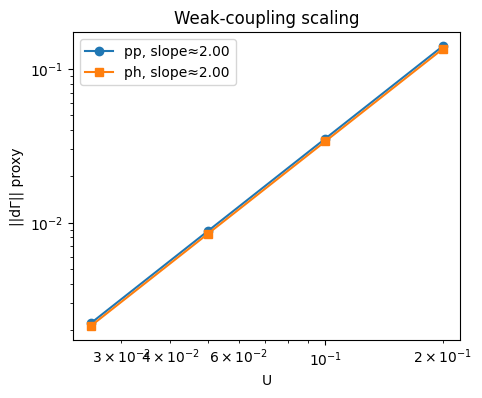

In [23]:
U_arr = np.array([d["U"] for d in scaling_data], dtype=float)
pp_arr = np.array([d["pp_norm"] for d in scaling_data], dtype=float)
ph_arr = np.array([d["ph_norm"] for d in scaling_data], dtype=float)

def fit_powerlaw(x, y):
    mask = (x > 0) & (y > 0)
    lx = np.log(x[mask])
    ly = np.log(y[mask])
    slope, intercept = np.polyfit(lx, ly, 1)
    return slope, intercept

s_pp, b_pp = fit_powerlaw(U_arr, pp_arr)
s_ph, b_ph = fit_powerlaw(U_arr, ph_arr)

print("pp slope ~", s_pp)
print("ph slope ~", s_ph)

fig, ax = plt.subplots(figsize=(5,4))
ax.loglog(U_arr, pp_arr, "o-", label=f"pp, slope≈{s_pp:.2f}")
ax.loglog(U_arr, ph_arr, "s-", label=f"ph, slope≈{s_ph:.2f}")
ax.set_xlabel("U")
ax.set_ylabel("||dΓ|| proxy")
ax.set_title("Weak-coupling scaling")
ax.legend()
plt.show()


# 3. SU(2) spin symmetry

## What is tested
For a spin-rotation-invariant Hubbard interaction and a spin-degenerate one-body model, the spin blocks should satisfy symmetry relations.

## Expected physics
For the simple SU(2)-symmetric benchmark:
- \(\Gamma_{\uparrow\uparrow\uparrow\uparrow} = \Gamma_{\downarrow\downarrow\downarrow\downarrow}\)
- \(\Gamma_{\uparrow\downarrow\uparrow\downarrow} = \Gamma_{\downarrow\uparrow\downarrow\uparrow}\)
- corresponding ph kernels in up and down sectors should match

This should hold both at the bare-vertex level and in the one-loop correction if the model and flow preserve spin symmetry.

## Important restriction
Use a benchmark with:
- no SOC,
- no spin splitting,
- spin-degenerate patch sets.

That means using your spinful model with spin-degenerate one-body blocks, not a symmetry-broken case.


## Cell 8 — Bare SU(2) block comparison

In [26]:
model, mu, patchsets = build_reference_model_and_patchsets(
    model_name="kane_mele",
    parameters={"t": 1.0, "l1": 0.0, "l2": 0.0},  # spin-degenerate
    filling=0.50,
    Npatch=12,
)

interaction = make_interaction(model, U=1.0, V=0.0)
gamma = build_gamma_tensors(interaction, patchsets)

print("rel[uuuu vs dddd] =", relative_diff(gamma[("up","up","up","up")], gamma[("dn","dn","dn","dn")]))
print("rel[udud vs dudu] =", relative_diff(gamma[("up","dn","up","dn")], gamma[("dn","up","dn","up")]))
print("rel[uddu vs duud] =", relative_diff(gamma[("up","dn","dn","up")], gamma[("dn","up","up","dn")]))


rel[uuuu vs dddd] = 0.0
rel[udud vs dudu] = 0.0
rel[uddu vs duud] = 0.0


## Cell 9 — One-loop SU(2) kernel comparison

In [28]:
Q = pick_test_Qs(patchsets, n_pick=1)[0]
out = compute_basic_channel_set(gamma, patchsets, Q, T=0.20, nfreq=64)

print("rel[ph_uu vs ph_dd] =", relative_diff(out["ph_uu"].matrix, out["ph_dd"].matrix))
print("rel[phc_uu vs phc_dd] =", relative_diff(out["phc_uu"].matrix, out["phc_dd"].matrix))


rel[ph_uu vs ph_dd] = 0.0
rel[phc_uu vs phc_dd] = 0.0


# 4. Channel competition (physics test)

## What is tested
For weak-coupling kagome Hubbard in a standard spin-symmetric benchmark, check whether particle-hole channels are stronger than particle-particle.

## Expected physics
In weak coupling near the magnetic / density-wave regime, the **ph** sector is usually expected to dominate over **pp**, while pp remains subleading until the flow amplifies an attractive Cooper structure indirectly.

This is not a theorem for every filling, so the point here is not “prove the final phase”, but check whether the implementation produces a plausible hierarchy.

## Implementation
For a fixed \(Q\)-set, compare:
- \(\|K_{pp}\|\)
- \(\|K_{ph}\|\)
- \(\|K_{ph'}\|\)

## Interpretation
- If pp dominates everywhere immediately, be cautious.
- If ph is competitive or dominant in a weak Hubbard benchmark, that is more plausible.


## Cell 10 — Channel competition scan over Q

In [32]:
model, mu, patchsets = build_reference_model_and_patchsets(
    model_name="kane_mele",
    parameters={"t": 1.0, "l1": 0.0, "l2": 0.0},
    filling=0.50,
    Npatch=12,
)
interaction = make_interaction(model, U=0.10, V=0.0)
gamma = build_gamma_tensors(interaction, patchsets)

Q_list = pick_test_Qs(patchsets, n_pick=8)

comp = []
for i, Q in enumerate(Q_list):
    out = compute_basic_channel_set(gamma, patchsets, Q, T=0.20, nfreq=64)
    comp.append({
        "Q_index": i,
        "pp": kernel_norm(out["pp_ud_ud"]),
        "ph": kernel_norm(out["ph_uu"]),
        "phc": kernel_norm(out["phc_uu"]),
    })

comp


[{'Q_index': 0,
  'pp': 0.03527822628816318,
  'ph': 0.03385830176236922,
  'phc': 0.03385830176236922},
 {'Q_index': 1,
  'pp': 0.039603544069097364,
  'ph': 0.03800952845525286,
  'phc': 0.03800952845525286},
 {'Q_index': 2,
  'pp': 0.03431164791194224,
  'ph': 0.03293062750596681,
  'phc': 0.03293062750596681},
 {'Q_index': 3,
  'pp': 0.03752828295799902,
  'ph': 0.03601779518722136,
  'phc': 0.036017795187221355},
 {'Q_index': 4,
  'pp': 0.03527822628816307,
  'ph': 0.033858301762369224,
  'phc': 0.033858301762369224},
 {'Q_index': 5,
  'pp': 0.03960354406909737,
  'ph': 0.03800952845525286,
  'phc': 0.03800952845525286},
 {'Q_index': 6,
  'pp': 0.034311647911942196,
  'ph': 0.03293062750596677,
  'phc': 0.03293062750596677},
 {'Q_index': 7,
  'pp': 0.04618144452721196,
  'ph': 0.04432267291026178,
  'phc': 0.04432267291026178}]

## Cell 11 — Channel competition plot

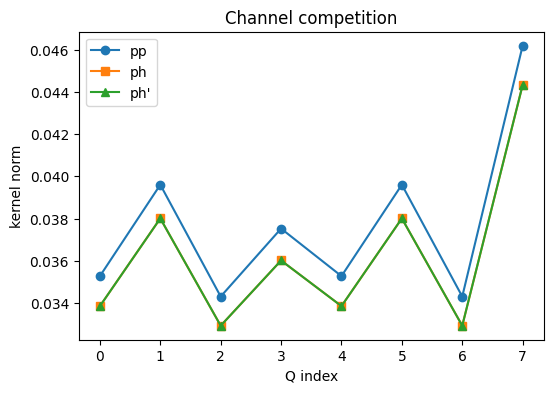

In [34]:
qidx = np.array([d["Q_index"] for d in comp], dtype=int)
ppv = np.array([d["pp"] for d in comp], dtype=float)
phv = np.array([d["ph"] for d in comp], dtype=float)
phcv = np.array([d["phc"] for d in comp], dtype=float)

fig, ax = plt.subplots(figsize=(6,4))
ax.plot(qidx, ppv, "o-", label="pp")
ax.plot(qidx, phv, "s-", label="ph")
ax.plot(qidx, phcv, "^-", label="ph'")
ax.set_xlabel("Q index")
ax.set_ylabel("kernel norm")
ax.set_title("Channel competition")
ax.legend()
plt.show()


# 5. Momentum-structure sanity

## What is tested
Does the kernel vary with \(Q\) in a structured way, rather than showing random spikes?

## Expected physics
A physically correct implementation should produce a momentum dependence that is:
- reproducible,
- symmetry-related where appropriate,
- not dominated by isolated nonsensical spikes.

With finite patching it will not be perfectly smooth, but it should not look random.

## Implementation
Plot \(\|K(Q)\|\) vs \(Q\)-index for several channels.

## Interpretation
- mild variation / symmetry-related repetition is normal,
- isolated giant spikes at seemingly random indices are suspicious,
- if the pattern changes drastically when you rerun with the same input, that is bad.


## Cell 12 — Momentum-structure sanity plots

Reuse the `comp` data from the previous section.


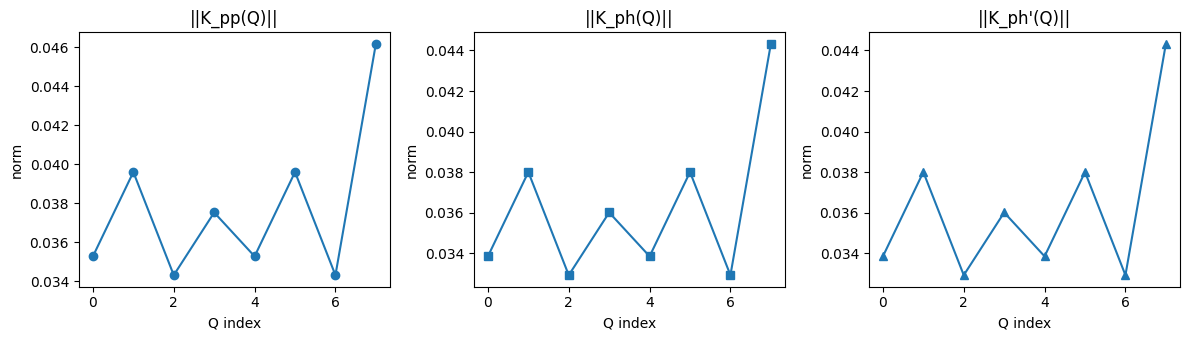

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharex=True)

axes[0].plot(qidx, ppv, "o-")
axes[0].set_title("||K_pp(Q)||")

axes[1].plot(qidx, phv, "s-")
axes[1].set_title("||K_ph(Q)||")

axes[2].plot(qidx, phcv, "^-")
axes[2].set_title("||K_ph'(Q)||")

for ax in axes:
    ax.set_xlabel("Q index")
    ax.set_ylabel("norm")

plt.tight_layout()
plt.show()


# 6. Flow stability test

## What is tested
Run a short flow and see whether the evolution is numerically sane.

## Expected physics
For weak coupling:
- no immediate divergence,
- leading eigenvalue should grow smoothly,
- no violent oscillation in a few steps.

## Implementation
Use your existing Module 4 solver exactly as it is.

## Interpretation
- immediate blow-up at weak coupling is bad,
- strong jagged jumps step-to-step suggest either step-size or routing problems,
- a smooth monotone or gently varying trend is reasonable.


## Cell 13 — Short flow run

In [39]:
if HAS_FLOW_SOLVER:
    model, mu, patchsets = build_reference_model_and_patchsets(
        model_name="kane_mele",
        parameters={"t": 1.0, "l1": 0.0, "l2": 0.0},
        filling=0.50,
        Npatch=10,
    )
    interaction = make_interaction(model, U=0.10, V=0.0)
    bare_gamma = BareVertexFromInteraction(interaction, patchsets)
    diagnoser = KagomeOrderDiagnoser(patchsets_by_spin=patchsets)

    solver = FRGFlowSolver(
        patchsets=patchsets,
        bare_gamma=bare_gamma,
        diagnoser=diagnoser,
        T_start=0.40,
        T_stop=0.10,
        n_steps=6,
        nfreq=32,
        diagnose_every=1,
    )
    history = solver.run()
    for h in history:
        print(h.summary_dict())
else:
    print("Skip: FRGFlowSolver not importable.")


{'step_index': 0, 'temperature': 0.4, 'dT': 0.0, 'channel_norm': 0.0, 'rhs_norm': 0.0, 'accepted_substeps': 0, 'max_rel_update': 0.0, 'instability': False, 'instability_reason': None, 'leading_channel_name': 'pp_singlet_sz0', 'leading_Q': [0.0, 0.0], 'leading_eigenvalue_abs': 0.6666732408717356, 'leading_order_label': 'unclassified', 'diagnosis_payload': {'kernel': 'pp_singlet_sz0', 'Q': [0.0, 0.0], 'coarse_label': 'pp_even', 'coarse_score': 0.9999997265545568, 'paper_label': 'unclassified', 'paper_score': 0.0, 'recognition_status': 'novel_candidate', 'top_template_name': 'fSC_BC', 'top_template_score': 4.91730361410824e-35, 'spin_sector': 'charge/singlet', 'channel_sector': 'pp', 'leg_spin_structure': ('up', 'dn'), 'degeneracy': 1, 'internal_mode': {'channel_sector': 'pp', 'spin_sector': 'charge/singlet', 'leg_spin_structure': ('up', 'dn'), 'tensor_basis_shape': (10, 3, 3, 1), 'dominant_pair': (1, 2), 'same_sublattice_weight': 2.335669493480872e-35, 'inter_sublattice_weight': 1.0, 'pa

## Cell 14 — Flow-stability plots

C:\Users\mli826\AppData\Local\Temp\ipykernel_36020\203838123.py:12: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  ax.set_yscale("log")


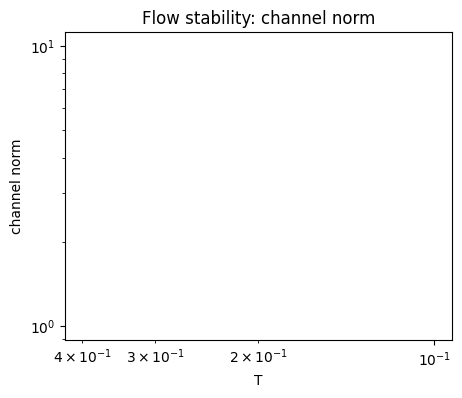

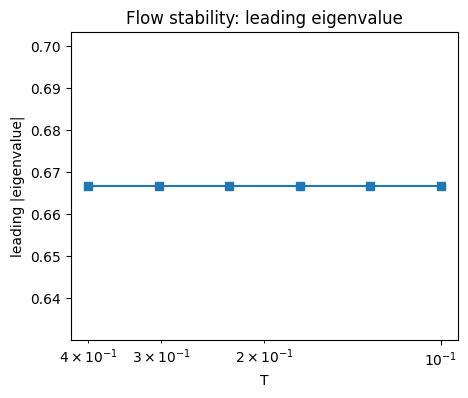

In [41]:
if HAS_FLOW_SOLVER:
    temps = np.array([h.temperature for h in history], dtype=float)
    norms = np.array([h.channel_norm for h in history], dtype=float)
    leigs = np.array([
        np.nan if h.leading_eigenvalue_abs is None else h.leading_eigenvalue_abs
        for h in history
    ], dtype=float)

    fig, ax = plt.subplots(figsize=(5,4))
    ax.plot(temps, norms, "o-")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.invert_xaxis()
    ax.set_xlabel("T")
    ax.set_ylabel("channel norm")
    ax.set_title("Flow stability: channel norm")
    plt.show()

    fig, ax = plt.subplots(figsize=(5,4))
    ax.plot(temps, leigs, "s-")
    ax.set_xscale("log")
    ax.invert_xaxis()
    ax.set_xlabel("T")
    ax.set_ylabel("leading |eigenvalue|")
    ax.set_title("Flow stability: leading eigenvalue")
    plt.show()


# 7. Order-diagnosis consistency

## What is tested
Check whether the diagnosed leading order is stable across nearby flow steps.

## Expected physics
At weak coupling and over a short, non-divergent flow:
- the leading label should usually remain stable or change only in a physically interpretable way,
- random switching every step is suspicious.

## Implementation
Read the stored diagnosis payloads from the flow history.

## Interpretation
- stable label = good sign,
- erratic switching = either channels are nearly degenerate or the implementation / discretization is noisy,
- if switching happens only when eigenvalues are nearly equal, that is less alarming.


## Cell 15 — Order label trace

In [53]:
if HAS_FLOW_SOLVER:
    rows = []
    for h in history:
        rows.append({
            "T": h.temperature,
            "leading_channel": h.leading_channel_name,
            "leading_eig": h.leading_eigenvalue_abs,
            "label": h.leading_order_label,
        })
    rows


## Cell 16 — Diagnose interpretation checklist

When you inspect the output, ask:

1. **Zero test**  
   Are all norms essentially zero?

2. **Weak-coupling scaling**  
   Is the fitted log-log slope close to 2?

3. **SU(2) symmetry**  
   Are up/down sectors numerically equal in the spin-symmetric benchmark?

4. **Channel competition**  
   Does ph look competitive or dominant in a weak Hubbard benchmark?

5. **Momentum structure**  
   Does Q-dependence look structured rather than random?

6. **Flow stability**  
   Does the flow remain smooth for several weak-coupling steps?

7. **Order consistency**  
   Does the phase label stay reasonably stable?

If most of these pass, then your implementation is much more likely to be physically correct.
